In [3]:
import os
import numpy as np
import pandas as pd

# Define your directory path matching your setup
data_dir = r"C:\Users\ACER\tinyml-iot-security\data"
os.makedirs(data_dir, exist_ok=True)

# Set seeds for reproducibility
np.random.seed(42)
num_samples = 2000
window_length = 64
num_features = 5 # Simulating PM10, eTVOC, NO, NO2, CO2 channels

data_list = []

for i in range(num_samples):
    # Determine segment behavior type: 0 = Nominal, 1 = Freeze, 2 = Replay
    label = np.random.choice([0, 1, 2], p=[0.6, 0.2, 0.2])
    
    # Base Generation: Create normal varying environmental waves
    base_signal = np.sin(np.linspace(0, 4 * np.pi, window_length)).reshape(-1, 1)
    noise = np.random.normal(0, 0.1, (window_length, num_features))
    features = np.repeat(base_signal, num_features, axis=1) + noise + 2.0
    
    # Inject Freeze Attack
    if label == 1:
        freeze_start = np.random.randint(10, 30)
        freeze_value = features[freeze_start].copy()
        features[freeze_start:] = freeze_value
        
    # Inject Replay Attack
    elif label == 2:
        replay_source_start = np.random.randint(0, 15)
        replay_length = 30
        replay_destination = window_length - replay_length
        replay_buffer = features[replay_source_start : replay_source_start + replay_length].copy()
        features[replay_destination:] = replay_buffer

    flattened_features = features.flatten()
    row_entry = {f"feat_{idx}": val for idx, val in enumerate(flattened_features)}
    row_entry["label"] = label
    data_list.append(row_entry)

df = pd.DataFrame(data_list)
output_path = os.path.join(data_dir, "synthetic_L64.csv")
df.to_csv(output_path, index=False)

print(f"Success! File saved with shape {df.shape} at:")
print(output_path)


Success! File saved with shape (2000, 321) at:
C:\Users\ACER\tinyml-iot-security\data\synthetic_L64.csv


In [4]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Define file paths
data_path = r"C:\Users\ACER\tinyml-iot-security\data\synthetic_L64.csv"

# 1. Load the synthetic windowed data
print("Loading dataset...")
df = pd.read_csv(data_path)

# 2. Separate features (X) and attack labels (y)
X = df.drop(columns=['label']).values
y = df['label'].values

# 3. Reshape features back to their original time-series window structure
# 64 time steps x 5 sensor features
X_reshaped = X.reshape(-1, 64, 5)

# 4. Split data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Print dataset characteristics to verify integrity
print("\n--- Pipeline Verification ---")
print(f"Total baseline samples loaded: {df.shape}")
print(f"Training features matrix shape: {X_train.shape} (Samples, Steps, Features)")
print(f"Testing features matrix shape:  {X_test.shape}")
print("\nClass distribution in training data:")
print(f"  Nominal (Normal operation):  {np.sum(y_train == 0)} samples")
print(f"  Freeze Attack detected:      {np.sum(y_train == 1)} samples")
print(f"  Replay Attack detected:      {np.sum(y_train == 2)} samples")


Loading dataset...

--- Pipeline Verification ---
Total baseline samples loaded: (2000, 321)
Training features matrix shape: (1600, 64, 5) (Samples, Steps, Features)
Testing features matrix shape:  (400, 64, 5)

Class distribution in training data:
  Nominal (Normal operation):  977 samples
  Freeze Attack detected:      316 samples
  Replay Attack detected:      307 samples


In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# 1. Define a lightweight 1D CNN Architecture suitable for TinyML
model = Sequential([
    # First Convolutional Layer to capture sensor trends over time
    Conv1D(filters=16, kernel_size=3, activation='relu', input_shape=(64, 5)),
    MaxPooling1D(pool_size=2),
    
    # Second Layer to compress features further
    Conv1D(filters=32, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    
    # Flatten and route to output classes (0=Normal, 1=Freeze, 2=Replay)
    Flatten(),
    Dense(32, activation='relu'),
    Dropout(0.2), # Prevents overfitting
    Dense(3, activation='softmax') # 3 target classes
])

# 2. Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Print the architectural summary to check model footprint size
print("--- Model Footprint Summary ---")
model.summary()

# 4. Train the model on your synthetic security dataset
print("\nStarting Model Training...")
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)


--- Model Footprint Summary ---


c:\Users\ACER\tinyml-iot-security\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 62, 16)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 31, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 29, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 14, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        14,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,291 (63.64 KB)

 Trainable params: 16,291 (63.64 KB)

 Non-trainable params: 0 (0.00 B)


Starting Model Training...
Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6775 - loss: 0.7555 - val_accuracy: 0.8850 - val_loss: 0.4884
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8938 - loss: 0.4082 - val_accuracy: 0.9325 - val_loss: 0.3099
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9175 - loss: 0.3015 - val_accuracy: 0.9350 - val_loss: 0.2611
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9250 - loss: 0.3017 - val_accuracy: 0.9350 - val_loss: 0.2465
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9325 - loss: 0.2660 - val_accuracy: 0.9250 - val_loss: 0.2384
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9194 - loss: 0.2911 - val_accuracy: 0.9250 - val_loss: 0.2360
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9231 - loss: 0.2568 - val_accuracy: 0.9250 - val_loss: 0.2268
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9250 - loss: 0.2457 - val

 Saved trained model artifact to: C:\Users\ACER\tinyml-iot-security\models\tinyml_freeze_replay_model.keras
 Test Accuracy: 93.50%
 Test Loss: 0.1946


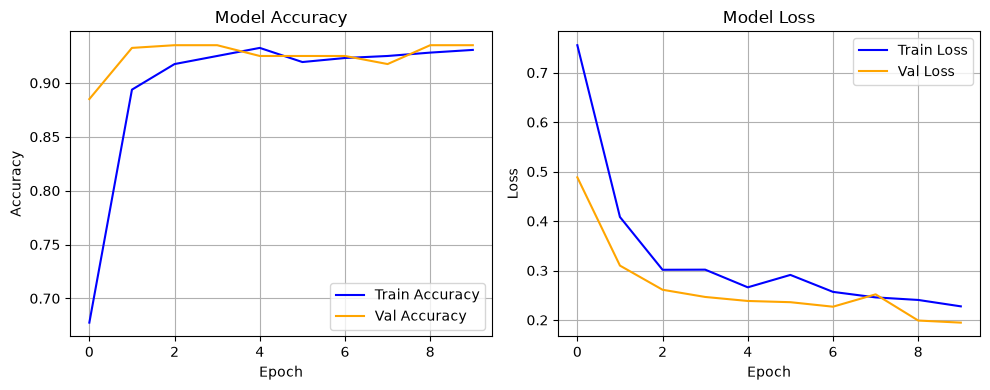

 Saved performance visualization plot to: C:\Users\ACER\tinyml-iot-security\results\training_performance.png


In [6]:
import matplotlib.pyplot as plt
import os

# Define export directory paths
models_dir = r"C:\Users\ACER\tinyml-iot-security\models"
results_dir = r"C:\Users\ACER\tinyml-iot-security\results"

# 1. Save the trained Keras model artifact
model_save_path = os.path.join(models_dir, "tinyml_freeze_replay_model.keras")
model.save(model_save_path)
print(f" Saved trained model artifact to: {model_save_path}")

# 2. Evaluate the model on unseen test data
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f" Test Accuracy: {test_acc*100:.2f}%")
print(f" Test Loss: {test_loss:.4f}")

# 3. Plot training and validation accuracy curves
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# 4. Plot training and validation loss curves
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plot_save_path = os.path.join(results_dir, "training_performance.png")
plt.savefig(plot_save_path)
plt.show()
print(f" Saved performance visualization plot to: {plot_save_path}")


In [7]:
import tensorflow as tf
import os

# Define storage locations
models_dir = r"C:\Users\ACER\tinyml-iot-security\models"
tflite_output_path = os.path.join(models_dir, "freeze_replay_detector.tflite")

# 1. Initialize the TFLite Converter from your trained model
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# 2. Enable post-training quantization configurations for edge optimization
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# 3. Convert the architecture structure
tflite_quant_model = converter.convert()

# 4. Save the compiled binary output flatbuffer
with open(tflite_output_path, "wb") as f:
    f.write(tflite_quant_model)

# 5. Measure structural storage savings footprint
original_size = os.path.getsize(os.path.join(models_dir, "tinyml_freeze_replay_model.keras")) / 1024
tflite_size = os.path.getsize(tflite_output_path) / 1024

print("--- TinyML Compression Metrics ---")
print(f"Original Keras Model Size: {original_size:.2f} KB")
print(f"Quantized TFLite Model Size: {tflite_size:.2f} KB")
print(f"Footprint Reduction: {((original_size - tflite_size) / original_size) * 100:.1f}% smaller!")


INFO:tensorflow:Assets written to: C:\Users\ACER\AppData\Local\Temp\tmp62lt7749\assets


INFO:tensorflow:Assets written to: C:\Users\ACER\AppData\Local\Temp\tmp62lt7749\assets


Saved artifact at 'C:\Users\ACER\AppData\Local\Temp\tmp62lt7749'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 5), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  1484571670096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1484571669136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1484571670864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1484571671632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1484571669328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1484571671824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1484571670480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1484571672208: TensorSpec(shape=(), dtype=tf.resource, name=None)
--- TinyML Compression Metrics ---
Original Keras Model Size: 229.69 KB
Quantized TFLite Model Size: 24.62 KB
Footprint Reduction: 89.3% smaller!
